# Cleaning Data Manually Again

In [1076]:
#importing necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [1077]:
# Loading File
blinkit = pd.read_csv("Existing-Files/blinkit-raw.csv", usecols=[0,1,2,3,4,5,6,7,8,9])
blinkit

/var/folders/0y/_77mc7f96s972qsnsgpfhw_40000gn/T/ipykernel_27333/3472362263.py:2: DtypeWarning: Columns (0,2,4,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  blinkit = pd.read_csv("Existing-Files/blinkit-raw.csv", usecols=[0,1,2,3,4,5,6,7,8,9])


,item_id,item_name,manufacturer_id,manufacturer_name,city_id,city_name,category,date,qty_sold,mrp
0,10174324,Chaayos Festive Tea Gift Box,1546,Sunshine Teahouse Pvt. Ltd.,2,Mumbai,Cold Drinks & Juices,01/12/2024,3,1647
1,10174324,Chaayos Festive Tea Gift Box,1546,Sunshine Teahouse Pvt. Ltd.,15,Kolkata,Cold Drinks & Juices,01/12/2024,1,549
2,10074976,Chaayos Masala Tea(Pouch),1546,Sunshine Teahouse Pvt. Ltd.,1,Bengaluru,"Tea, Coffee & Milk Drinks",01/12/2024,29,4031
3,10165477,Chaayos Masala Instant Tea Premix Regular Suga...,1546,Sunshine Teahouse Pvt. Ltd.,66,Chandigarh,"Tea, Coffee & Milk Drinks",01/12/2024,6,1134
4,10165477,Chaayos Masala Instant Tea Premix Regular Suga...,1546,Sunshine Teahouse Pvt. Ltd.,211,Kota,"Tea, Coffee & Milk Drinks",01/12/2024,2,378
...,...,...,...,...,...,...,...,...,...,...
230448,10247656,Chaayos Instant Tea Premix (Masala)(Pouch),1546,Sunshine Teahouse Pvt. Ltd.,133,Firozabad,"Tea, Coffee & Milk Drinks",17/02/2026,1,59
230449,10247656,Chaayos Instant Tea Premix (Masala)(Pouch),1546,Sunshine Teahouse Pvt. Ltd.,175,Puducherry,"Tea, Coffee & Milk Drinks",17/02/2026,2,118
230450,10247656,Chaayos Instant Tea Premix (Masala)(Pouch),1546,Sunshine Teahouse Pvt. Ltd.,305,Bokaro,"Tea, Coffee & Milk Drinks",17/02/2026,1,59
230451,10247656,Chaayos Instant Tea Premix (Masala)(Pouch),1546,Sunshine Teahouse Pvt. Ltd.,55,Jalandhar,"Tea, Coffee & Milk Drinks",17/02/2026,3,177


In [1078]:
#Removing Duplicate Headers
dup_header = blinkit.index[blinkit['item_id'] == 'item_id']
print(blinkit.loc[dup_header])
blinkit = blinkit[blinkit['item_id'] != 'item_id']
blinkit = blinkit.reset_index(drop = True)
print("=====================================================================================================================")
print(blinkit.loc[dup_header])

        item_id  item_name  manufacturer_id  manufacturer_name  city_id  \
220035  item_id  item_name  manufacturer_id  manufacturer_name  city_id   

        city_name  category  date  qty_sold  mrp  
220035  city_name  category  date  qty_sold  mrp  
         item_id                                          item_name  \
220035  10165635  Chaayos Cardamom Instant Tea Premix Regular Su...   

       manufacturer_id            manufacturer_name city_id city_name  \
220035            1546  Sunshine Teahouse Pvt. Ltd.     184  Durgapur   

                         category        date qty_sold  mrp  
220035  Tea, Coffee & Milk Drinks  04/02/2026        1  168  


In [1079]:
blinkit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230452 entries, 0 to 230451
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   item_id            230452 non-null  object
 1   item_name          230452 non-null  object
 2   manufacturer_id    230452 non-null  object
 3   manufacturer_name  230452 non-null  object
 4   city_id            230452 non-null  object
 5   city_name          230452 non-null  object
 6   category           230452 non-null  object
 7   date               230452 non-null  object
 8   qty_sold           230452 non-null  object
 9   mrp                230452 non-null  object
dtypes: object(10)
memory usage: 17.6+ MB


In [1080]:
# Changing datatypes of columns/ Striping blank spaces from string

str_cols     = ["item_name", "manufacturer_name", "city_name", "category"]
numeric_cols = ["item_id", "manufacturer_id", "city_id", "qty_sold", "mrp"]

for col in str_cols:
    blinkit[col] = blinkit[col].str.strip().astype("string")

for col in numeric_cols:
    blinkit[col] = pd.to_numeric(blinkit[col])

blinkit["date"] = pd.to_datetime(blinkit["date"], format="mixed")

In [1081]:
blinkit.rename(columns={'item_id':'blinkit_identifier'}, inplace=True)
blinkit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230452 entries, 0 to 230451
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   blinkit_identifier  230452 non-null  int64         
 1   item_name           230452 non-null  string        
 2   manufacturer_id     230452 non-null  int64         
 3   manufacturer_name   230452 non-null  string        
 4   city_id             230452 non-null  int64         
 5   city_name           230452 non-null  string        
 6   category            230452 non-null  string        
 7   date                230452 non-null  datetime64[ns]
 8   qty_sold            230452 non-null  int64         
 9   mrp                 230452 non-null  int64         
dtypes: datetime64[ns](1), int64(5), string(4)
memory usage: 17.6 MB


In [1082]:
blinkit.head()

,blinkit_identifier,item_name,manufacturer_id,manufacturer_name,city_id,city_name,category,date,qty_sold,mrp
0,10174324,Chaayos Festive Tea Gift Box,1546,Sunshine Teahouse Pvt. Ltd.,2,Mumbai,Cold Drinks & Juices,2024-01-12,3,1647
1,10174324,Chaayos Festive Tea Gift Box,1546,Sunshine Teahouse Pvt. Ltd.,15,Kolkata,Cold Drinks & Juices,2024-01-12,1,549
2,10074976,Chaayos Masala Tea(Pouch),1546,Sunshine Teahouse Pvt. Ltd.,1,Bengaluru,"Tea, Coffee & Milk Drinks",2024-01-12,29,4031
3,10165477,Chaayos Masala Instant Tea Premix Regular Suga...,1546,Sunshine Teahouse Pvt. Ltd.,66,Chandigarh,"Tea, Coffee & Milk Drinks",2024-01-12,6,1134
4,10165477,Chaayos Masala Instant Tea Premix Regular Suga...,1546,Sunshine Teahouse Pvt. Ltd.,211,Kota,"Tea, Coffee & Milk Drinks",2024-01-12,2,378


## PIVOT TABLES

In [1083]:
top_5_cities = blinkit.groupby('city_name')['mrp'].agg('sum').sort_values(ascending= False).head().index.tolist()

In [1084]:
top_5_cities

['Delhi', 'Ghaziabad', 'Gurgaon', 'Bengaluru', 'Mumbai']

In [1085]:
blinkit['purchase_month_text'] = blinkit['date'].dt.month_name()
blinkit_top_cities = blinkit[blinkit['city_name'].isin(top_5_cities)].copy()

In [1086]:
blinkit_top_cities.head()

,blinkit_identifier,item_name,manufacturer_id,manufacturer_name,city_id,city_name,category,date,qty_sold,mrp,purchase_month_text
0,10174324,Chaayos Festive Tea Gift Box,1546,Sunshine Teahouse Pvt. Ltd.,2,Mumbai,Cold Drinks & Juices,2024-01-12,3,1647,January
2,10074976,Chaayos Masala Tea(Pouch),1546,Sunshine Teahouse Pvt. Ltd.,1,Bengaluru,"Tea, Coffee & Milk Drinks",2024-01-12,29,4031,January
6,10074976,Chaayos Masala Tea(Pouch),1546,Sunshine Teahouse Pvt. Ltd.,10,Ghaziabad,"Tea, Coffee & Milk Drinks",2024-01-12,46,7114,January
10,10165477,Chaayos Masala Instant Tea Premix Regular Suga...,1546,Sunshine Teahouse Pvt. Ltd.,9,Gurgaon,"Tea, Coffee & Milk Drinks",2024-01-12,31,5859,January
11,10074980,Chaayos Masala Chai Tea Bags,1546,Sunshine Teahouse Pvt. Ltd.,10,Ghaziabad,"Tea, Coffee & Milk Drinks",2024-01-12,19,3021,January


In [1087]:
blinkit_top_cities_pivot = blinkit_top_cities.pivot_table(values='mrp' , index = 'purchase_month_text', 
                                    columns = 'city_name', aggfunc='sum')

In [1088]:
blinkit_top_cities_pivot

city_name,Bengaluru,Delhi,Ghaziabad,Gurgaon,Mumbai
purchase_month_text,,,,,
April,971394,2356036,1048814,1040708,783893
August,1265990,3005469,1351624,1282042,1019865
December,1746520,4321508,1933247,1903806,1368140
February,1139528,2701938,1195589,1238010,901379
January,1735668,4174674,1795460,1782814,1378466
July,1196637,2716965,1251419,1197521,946465
June,1124291,2573438,1203507,1181202,809498
March,997276,2357802,1004406,1068081,805139
May,1162178,2621712,1170100,1174189,904209


In [1089]:
#Setting months in chronological order
blinkit_top_cities_pivot.reset_index(inplace=True)
blinkit_top_cities_pivot['month_no'] = pd.to_datetime(blinkit_top_cities_pivot['purchase_month_text'], format="%B").dt.month

In [1090]:
blinkit_top_cities_pivot

city_name,purchase_month_text,Bengaluru,Delhi,Ghaziabad,Gurgaon,Mumbai,month_no
0,April,971394,2356036,1048814,1040708,783893,4
1,August,1265990,3005469,1351624,1282042,1019865,8
2,December,1746520,4321508,1933247,1903806,1368140,12
3,February,1139528,2701938,1195589,1238010,901379,2
4,January,1735668,4174674,1795460,1782814,1378466,1
5,July,1196637,2716965,1251419,1197521,946465,7
6,June,1124291,2573438,1203507,1181202,809498,6
7,March,997276,2357802,1004406,1068081,805139,3
8,May,1162178,2621712,1170100,1174189,904209,5
9,November,1218930,3161555,1475466,1334329,837280,11


In [1091]:
blinkit_top_cities_pivot.sort_values(by = 'month_no', inplace=True)

In [1092]:
blinkit_top_cities_pivot.drop('month_no', axis=1, inplace=True)
blinkit_top_cities_pivot.set_index("purchase_month_text", inplace=True)

<Axes: xlabel='purchase_month_text'>

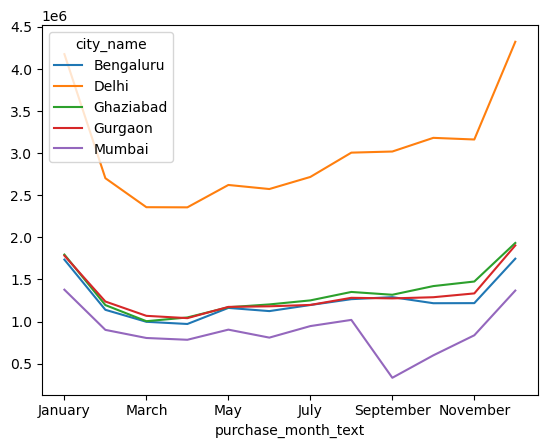

In [1093]:
blinkit_top_cities_pivot.plot(kind= "line")

## MERGING DATAFRAMES

In [1094]:
sku_mapping = pd.read_csv("/Users/akshaybisht/Desktop/E-Automation/Existing-Files/SKU Mapping.csv")
sku_mapping.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Sumo ID               17 non-null     float64
 1   Category              24 non-null     object 
 2   SKU                   24 non-null     object 
 3   MRP                   17 non-null     float64
 4   Blinkit Identifier    22 non-null     float64
 5   Status                17 non-null     object 
 6   Instamart Identifier  21 non-null     float64
 7   Status.1              17 non-null     object 
 8   Zepto Identifier      21 non-null     object 
 9   Status.2              17 non-null     object 
 10  FKM Identifier        10 non-null     object 
 11  Status.3              17 non-null     object 
 12  BB Identifier         16 non-null     float64
 13  Status.4              17 non-null     object 
dtypes: float64(5), object(9)
memory usage: 2.8+ KB


In [1095]:
for obj_col in sku_mapping.select_dtypes(include = "object"):
    sku_mapping[obj_col] = sku_mapping[obj_col].astype("string").str.strip()

In [1096]:
sku_mapping.drop(columns = ["Status","Status.1","Status.2","Status.3","Status.4"], inplace=True)
sku_mapping.rename(columns={"Blinkit Identifier":"blinkit_identifier"}, inplace=True)
sku_mapping_blinkit = sku_mapping.loc[0:,"Sumo ID":"blinkit_identifier"].copy()

In [1097]:
sku_mapping_blinkit

,Sumo ID,Category,SKU,MRP,blinkit_identifier
0,1505.0,Chai Patti,Chaayos Adrak Elaichi 100g,139.0,10074977.0
1,5751.0,Chai Patti,Chaayos Adrak Elaichi 250g,200.0,10191319.0
2,6330.0,Chai Patti,Chaayos Adrak Elaichi 500g,370.0,10256646.0
3,1504.0,Chai Patti,Chaayos Masala Tea 100g,139.0,10074976.0
4,5749.0,Chai Patti,Chaayos Masala Tea 250g,190.0,10191317.0
5,6331.0,Chai Patti,Chaayos Masala Tea 500g,350.0,10256497.0
6,5916.0,Ice Tea,Chaayos Lemon Iced Tea Premix,106.0,10204493.0
7,5915.0,Ice Tea,Chaayos Peach Iced Tea Premix,106.0,10204489.0
8,1960.0,Tea Bag,Chaayos Masala Tea Bag,159.0,10074980.0
9,3672.0,Tea Bag,Chaayos Detox Kahwa Tea Bag,209.0,10248786.0


In [1098]:
merged = blinkit.merge(sku_mapping_blinkit, on="blinkit_identifier", how = "left")
merged

,blinkit_identifier,item_name,manufacturer_id,manufacturer_name,city_id,city_name,category,date,qty_sold,mrp,purchase_month_text,Sumo ID,Category,SKU,MRP
0,10174324,Chaayos Festive Tea Gift Box,1546,Sunshine Teahouse Pvt. Ltd.,2,Mumbai,Cold Drinks & Juices,2024-01-12,3,1647,January,NaN,Discontinue,Discontinue,NaN
1,10174324,Chaayos Festive Tea Gift Box,1546,Sunshine Teahouse Pvt. Ltd.,15,Kolkata,Cold Drinks & Juices,2024-01-12,1,549,January,NaN,Discontinue,Discontinue,NaN
2,10074976,Chaayos Masala Tea(Pouch),1546,Sunshine Teahouse Pvt. Ltd.,1,Bengaluru,"Tea, Coffee & Milk Drinks",2024-01-12,29,4031,January,1504.0,Chai Patti,Chaayos Masala Tea 100g,139.0
3,10165477,Chaayos Masala Instant Tea Premix Regular Suga...,1546,Sunshine Teahouse Pvt. Ltd.,66,Chandigarh,"Tea, Coffee & Milk Drinks",2024-01-12,6,1134,January,4972.0,Premix,Chaayos Masala Tea Premix Pack of 15,168.0
4,10165477,Chaayos Masala Instant Tea Premix Regular Suga...,1546,Sunshine Teahouse Pvt. Ltd.,211,Kota,"Tea, Coffee & Milk Drinks",2024-01-12,2,378,January,4972.0,Premix,Chaayos Masala Tea Premix Pack of 15,168.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230447,10247656,Chaayos Instant Tea Premix (Masala)(Pouch),1546,Sunshine Teahouse Pvt. Ltd.,133,Firozabad,"Tea, Coffee & Milk Drinks",2026-02-17,1,59,February,6097.0,Premix,Chaayos Masala Premix Pack of 4,59.0
230448,10247656,Chaayos Instant Tea Premix (Masala)(Pouch),1546,Sunshine Teahouse Pvt. Ltd.,175,Puducherry,"Tea, Coffee & Milk Drinks",2026-02-17,2,118,February,6097.0,Premix,Chaayos Masala Premix Pack of 4,59.0
230449,10247656,Chaayos Instant Tea Premix (Masala)(Pouch),1546,Sunshine Teahouse Pvt. Ltd.,305,Bokaro,"Tea, Coffee & Milk Drinks",2026-02-17,1,59,February,6097.0,Premix,Chaayos Masala Premix Pack of 4,59.0
230450,10247656,Chaayos Instant Tea Premix (Masala)(Pouch),1546,Sunshine Teahouse Pvt. Ltd.,55,Jalandhar,"Tea, Coffee & Milk Drinks",2026-02-17,3,177,February,6097.0,Premix,Chaayos Masala Premix Pack of 4,59.0
